In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( 
    classification_report, 
    confusion_matrix
)
import joblib

from src.db_utils import load_sql
from src.text_preprocessing import preprocess_text

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Модули импортированы")

Модули импортированы


In [ ]:
df = load_sql("SELECT * FROM documents")
print(f"Всего отзывов: {len(df)}")

vectorizer = joblib.load('../models/tfidf_vectorizer_v1.pkl')

df['clean_text'] = df['text'].apply(preprocess_text)

X = vectorizer.fit_transform(df['clean_text'])
y = df['category']

print(f"Размер матрицы признаков: {X.shape}")
print(f"Распределение классов:\n{y.value_counts()}")

Всего отзывов: 131669
Размер матрицы признаков: (131669, 10000)
Распределение классов:
category
pos    87138
neu    24704
neg    19827
Name: count, dtype: int64


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train: {X_train.shape[0]} отзывов")
print(f"Validation: {X_val.shape[0]} отзывов")

print(f"\nРаспределение классов в train:")
print(y_train.value_counts(normalize=True))

print(f"\nРаспределение классов в validation:")
print(y_val.value_counts(normalize=True))

Train: 105335 отзывов
Validation: 26334 отзывов

Распределение классов в train:
category
pos    0.661793
neu    0.187620
neg    0.150586
Name: proportion, dtype: float64

Распределение классов в validation:
category
pos    0.661806
neu    0.187628
neg    0.150566
Name: proportion, dtype: float64


In [8]:
model = LogisticRegression(
    max_iter=10000,
    class_weight='balanced',
    random_state=42
)

print("Обучаем модель...")
model.fit(X_train, y_train)
print("Модель обучена!")

Обучаем модель...
Модель обучена!


In [11]:
y_pred = model.predict(X_val)

y_proba = model.predict_proba(X_val)

print(f"Первые 5 предсказаний:")
for i in range(5):
    print(f"  Истинный: {y_val.iloc[i]}, Предсказанный: {y_pred[i]}")
    print(f"  Вероятности: neg={y_proba[i][0]:.3f}, neu={y_proba[i][1]:.3f}, pos={y_proba[i][2]:.3f}")
    print()

Первые 5 предсказаний:
  Истинный: pos, Предсказанный: pos
  Вероятности: neg=0.245, neu=0.358, pos=0.397

  Истинный: pos, Предсказанный: pos
  Вероятности: neg=0.026, neu=0.135, pos=0.838

  Истинный: neg, Предсказанный: neg
  Вероятности: neg=0.689, neu=0.245, pos=0.066

  Истинный: neg, Предсказанный: neg
  Вероятности: neg=0.655, neu=0.197, pos=0.148

  Истинный: neu, Предсказанный: neg
  Вероятности: neg=0.558, neu=0.346, pos=0.096



In [13]:
report = classification_report(y_val, y_pred)
print("Отчёт по классификации:")
print(report)

Отчёт по классификации:
              precision    recall  f1-score   support

         neg       0.59      0.72      0.65      3965
         neu       0.37      0.49      0.42      4941
         pos       0.89      0.76      0.82     17428

    accuracy                           0.71     26334
   macro avg       0.62      0.66      0.63     26334
weighted avg       0.75      0.71      0.72     26334



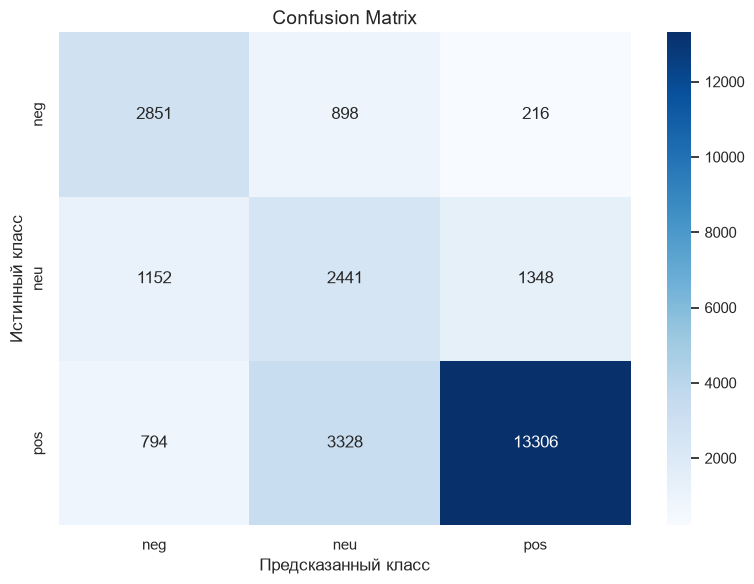


Confusion Matrix:
[[ 2851   898   216]
 [ 1152  2441  1348]
 [  794  3328 13306]]


In [ ]:

cm = confusion_matrix(y_val, y_pred, labels=['neg', 'neu', 'pos'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,       
    fmt='d',              
    cmap='Blues',         
    xticklabels=['neg', 'neu', 'pos'],
    yticklabels=['neg', 'neu', 'pos'],
    ax=ax
)

plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=150)
plt.show()

print("\nConfusion Matrix:")
print(cm)

In [ ]:
joblib.dump(model, '../models/logreg_v1.pkl')
print("Модель сохранена: models/logreg_v1.pkl")

Модель сохранена: models/logreg_v1.pkl


In [ ]:
def predict_sentiment(text):
    clean = preprocess_text(text)
    X_new = vectorizer.transform([clean])
    
    pred_class = model.predict(X_new)[0]
    pred_proba = model.predict_proba(X_new)[0]
    
    result = {
        'text': text[:100] + ('...' if len(text) > 100 else ''),
        'predicted': pred_class,
        'probabilities': {
            'neg': pred_proba[0],
            'neu': pred_proba[1],
            'pos': pred_proba[2]
        }
    }
    
    return result

test_reviews = [
    "Этот фильм — полный отстой. Потраченное время.",
    "Отличное кино! Рекомендую всем посмотреть.",
    "Фильм как фильм. Ничего особенного.",
]

print("Тестовые предсказания:\n")
for review in test_reviews:
    result = predict_sentiment(review)
    print(f"Текст: {result['text']}")
    print(f"Предсказание: {result['predicted']}")
    print(f"Вероятности: neg={result['probabilities']['neg']:.3f}, "
          f"neu={result['probabilities']['neu']:.3f}, "
          f"pos={result['probabilities']['pos']:.3f}")
    print()

Тестовые предсказания:

Текст: Этот фильм — полный отстой. Потраченное время.
Предсказание: neg
Вероятности: neg=0.476, neu=0.401, pos=0.123

Текст: Отличное кино! Рекомендую всем посмотреть.
Предсказание: pos
Вероятности: neg=0.004, neu=0.024, pos=0.972

Текст: Фильм как фильм. Ничего особенного.
Предсказание: neu
Вероятности: neg=0.128, neu=0.854, pos=0.017

